Script TP1: Grupo 4

**PARTE 1: Familiarizandonos con la base EPH y limpieza**

Importo librerías y cargo las bases:

In [ ]:
import pandas as pd
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
ruta = "/content/drive/MyDrive/Taller de Programación '26/TP1"

base_2024 = pd.read_excel(os.path.join(ruta, "usu_individual_T424.xlsx"))
base_2025 = pd.read_excel(os.path.join(ruta, "usu_individual_T425.xlsx"))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**2.a)**
Selecciono las variables para las dos bases:

In [ ]:
variables = ['CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED', 'ESTADO', 'CAT_OCUP', 'EMPLEO', 'SECTOR', 'PP04C', 'PP04D_COD', 'P21', 'P47T', ## obligatorias 13
             'REGION','CH03',  ## adicionales 2
             'CODUSU', 'ANO4', 'TRIMESTRE', 'NRO_HOGAR', 'PONDERA', ## variables id 5
             ]
base_2024_tp1 = base_2024[variables].copy()

base_2025_tp1 = base_2025[variables].copy()


Revisión de los tipos de datos:


In [ ]:
tipo_datos = pd.DataFrame({
    'variable': variables,
    'tipo_2024': [base_2024_tp1[var].dtype for var in variables],
    'tipo_2025': [base_2025_tp1[var].dtype for var in variables]
})

tipo_datos['mismo_tipo'] = tipo_datos['tipo_2024'] == tipo_datos['tipo_2025']

tipo_datos

,variable,tipo_2024,tipo_2025,mismo_tipo
0,CH04,int64,int64,True
1,CH06,int64,int64,True
2,CH07,int64,int64,True
3,CH08,int64,int64,True
4,NIVEL_ED,int64,int64,True
5,ESTADO,int64,int64,True
6,CAT_OCUP,int64,int64,True
7,EMPLEO,float64,float64,True
8,SECTOR,float64,float64,True
9,PP04C,float64,float64,True


In [ ]:
tipo_datos.to_excel('tipo_datos.xlsx', index=False)

Armonización:

In [ ]:
base_2024_tp1['CODUSU'] = base_2024_tp1['CODUSU'].astype(str).str.strip()
base_2025_tp1['CODUSU'] = base_2025_tp1['CODUSU'].astype(str).str.strip()

variables_numericas = [var for var in variables if var != 'CODUSU']

for var in variables_numericas:
    base_2024_tp1[var] = pd.to_numeric(base_2024_tp1[var], errors='coerce')
    base_2025_tp1[var] = pd.to_numeric(base_2025_tp1[var], errors='coerce')

In [ ]:
# Chequeo de tipos finales
tipos_finales = pd.DataFrame({
    'variable': variables,
    'tipo_2024_final': [base_2024_tp1[var].dtype for var in variables],
    'tipo_2025_final': [base_2025_tp1[var].dtype for var in variables]
})

tipos_finales['mismo_tipo_final'] = (
    tipos_finales['tipo_2024_final'] == tipos_finales['tipo_2025_final']
)

tipos_finales

,variable,tipo_2024_final,tipo_2025_final,mismo_tipo_final
0,CH04,int64,int64,True
1,CH06,int64,int64,True
2,CH07,int64,int64,True
3,CH08,int64,int64,True
4,NIVEL_ED,int64,int64,True
5,ESTADO,int64,int64,True
6,CAT_OCUP,int64,int64,True
7,EMPLEO,float64,float64,True
8,SECTOR,float64,float64,True
9,PP04C,float64,float64,True


Con la armonización no se modificaron los tipos de las variables.
Ahora genero una única base en la cual trabajar:

In [ ]:
base_2024_tp1['anio_base'] = 2024
base_2025_tp1['anio_base'] = 2025

base_final = pd.concat(
    [base_2024_tp1, base_2025_tp1],
    ignore_index=True
)

##base_final.head()
##base_final.tail()


In [ ]:
print("Observaciones 2024:", base_2024_tp1.shape[0])
print("Observaciones 2025:", base_2025_tp1.shape[0])
print("Observaciones base final:", base_final.shape[0])

Observaciones 2024: 46860
Observaciones 2025: 43703
Observaciones base final: 90563


**2.b)**
Limpieza de valores sin sentido:

In [ ]:
import numpy as np
##miro cuántas celdas vacías hay antes:
base_final_limpia = base_final.copy()

nan_antes = base_final_limpia.isna().sum()
#nan_antes

A las Ns/Nr les dejo vacía la celda, lo mismo con los valores negativos en el ingreso:

In [ ]:
# NIVEL_ED: 9 = Ns/Nr
base_final_limpia.loc[base_final_limpia['NIVEL_ED'] == 9, 'NIVEL_ED'] = np.nan

# CAT_OCUP: 9 = Ns/Nr
base_final_limpia.loc[base_final_limpia['CAT_OCUP'] == 9, 'CAT_OCUP'] = np.nan

# EMPLEO: 9 = Ns/Nr
base_final_limpia.loc[base_final_limpia['EMPLEO'] == 9, 'EMPLEO'] = np.nan

# SECTOR: 9 = Ns/Nr
base_final_limpia.loc[base_final_limpia['SECTOR'] == 9, 'SECTOR'] = np.nan

# CH8: 9 = Ns/Nc
base_final_limpia.loc[base_final_limpia['CH08'] == 9, 'CH08'] = np.nan

# PP04C: 99 = Ns/Nr
base_final_limpia.loc[base_final_limpia['PP04C'] == 99, 'PP04C'] = np.nan

# Ingresos negativos: valores sin sentido / no respuesta
base_final_limpia.loc[base_final_limpia['P21'] < 0, 'P21'] = np.nan
base_final_limpia.loc[base_final_limpia['P47T'] < 0, 'P47T'] = np.nan

# Edad: CH06 no puede ser negativa
base_final_limpia.loc[base_final_limpia['CH06'] < 0,'CH06'] = np.nan

In [ ]:
#comparo con las celdas vacías que hay ahora
nan_despues = base_final_limpia.isna().sum()

comparacion_nan = pd.DataFrame({
    'variable': base_final_limpia.columns,
    'NaN_antes': nan_antes[base_final_limpia.columns].values,
    'NaN_despues': nan_despues[base_final_limpia.columns].values
})

comparacion_nan['nuevos_NaN_por_limpieza'] = (
    comparacion_nan['NaN_despues'] - comparacion_nan['NaN_antes']
)

comparacion_nan

,variable,NaN_antes,NaN_despues,nuevos_NaN_por_limpieza
0,CH04,0,0,0
1,CH06,0,553,553
2,CH07,0,0,0
3,CH08,0,156,156
4,NIVEL_ED,0,0,0
5,ESTADO,0,0,0
6,CAT_OCUP,0,6,6
7,EMPLEO,49733,49759,26
8,SECTOR,49733,51340,1607
9,PP04C,49733,55136,5403


In [ ]:
comparacion_nan.to_excel('comparacion_nan.xlsx', index=False)

**3)** Separo la base por ESTADO != 0 (respondieron la encuesta).

In [ ]:
respondieron = base_final_limpia[base_final_limpia['ESTADO'] != 0].copy()
norespondieron = base_final_limpia[base_final_limpia['ESTADO'] == 0].copy()
print("Hubo", len(norespondieron), "que no respondieron la pregunta ESTADO.")

Hubo 121 que no respondieron la pregunta ESTADO.


**4)** El análisis de formalidad aplica solo a quienes trabajan:

In [ ]:
ocupados = respondieron[(respondieron['ESTADO']==1)]

**5)** Creación de variables binaras

Se opta por crearlas sobre respondieron, y luego volver a crear ocupados para que ambas bases tengan todas las variables.

In [ ]:
# Función auxiliar:
# devuelve 1 si se cumple la condición positiva,
# 0 si se cumple la condición negativa,
# NaN si no hay información suficiente.
def crear_binaria(condicion_1, condicion_0):
    return np.select(
        [condicion_1, condicion_0],
        [1, 0],
        default=np.nan
    )


Variables sociodemográficas

In [ ]:
# Sexo: CH04
respondieron['mujer'] = crear_binaria(
    respondieron['CH04'] == 2,
    respondieron['CH04'] == 1
)

# Relación de parentesco: CH03
respondieron['jefe_hogar'] = crear_binaria(
    respondieron['CH03'] == 1,
    respondieron['CH03'].isin([2, 3, 4, 5, 6, 7, 8, 9, 10])
)

respondieron['conyuge_pareja'] = crear_binaria(
    respondieron['CH03'] == 2,
    respondieron['CH03'].isin([1, 3, 4, 5, 6, 7, 8, 9, 10])
)

respondieron['hijo_hogar'] = crear_binaria(
    respondieron['CH03'] == 3,
    respondieron['CH03'].isin([1, 2, 4, 5, 6, 7, 8, 9, 10])
)

# Estado civil: CH07
respondieron['con_pareja'] = crear_binaria(
    respondieron['CH07'].isin([1, 2]),      # unido/a o casado/a
    respondieron['CH07'].isin([3, 4, 5])   # separado/a, viudo/a o soltero/a
)

# Cobertura médica: CH08
# Tiene cobertura si declara obra social, prepaga, seguro público o combinaciones.
respondieron['tiene_cobertura_medica'] = crear_binaria(
    respondieron['CH08'].isin([1, 2, 3, 12, 13, 23, 123]),
    respondieron['CH08'] == 4
)

respondieron['sin_cobertura_medica'] = crear_binaria(
    respondieron['CH08'] == 4,
    respondieron['CH08'].isin([1, 2, 3, 12, 13, 23, 123])
)
# Nivel educativo: NIVEL_ED
respondieron['secundario_completo_o_mas'] = crear_binaria(
    respondieron['NIVEL_ED'].isin([4, 5, 6]),
    respondieron['NIVEL_ED'].isin([1, 2, 3, 7])
)

respondieron['superior_completo'] = crear_binaria(
    respondieron['NIVEL_ED'] == 6,
    respondieron['NIVEL_ED'].isin([1, 2, 3, 4, 5, 7])
)


Variables laborables

In [ ]:
# ESTADO: "OCUPADO"
respondieron['Ocupado'] = crear_binaria(
    respondieron['ESTADO'] == 1,
    respondieron['ESTADO'] != 1
)

# # ESTADO: "DESOCUPADO"
respondieron['Desocupado'] = crear_binaria(
    respondieron['ESTADO'] == 2,
    respondieron['ESTADO'] != 2
)

# ESTADO: "INACTIVO"
respondieron['Inactivo'] = crear_binaria(
    respondieron['ESTADO'] == 3,
    respondieron['ESTADO'] != 3
)

# Categoría ocupacional: CAT_OCUP
respondieron['patron'] = crear_binaria(
    respondieron['CAT_OCUP'] == 1,
    respondieron['CAT_OCUP'].isin([2, 3, 4])
)

respondieron['cuenta_propia'] = crear_binaria(
    respondieron['CAT_OCUP'] == 2,
    respondieron['CAT_OCUP'].isin([1, 3, 4])
)

respondieron['asalariado'] = crear_binaria(
    respondieron['CAT_OCUP'] == 3,
    respondieron['CAT_OCUP'].isin([1, 2, 4])
)

respondieron['trabajador_familiar_sin_remuneracion'] = crear_binaria(
    respondieron['CAT_OCUP'] == 4,
    respondieron['CAT_OCUP'].isin([1, 2, 3])
)

# EMPLEO: 1 = Formal, 2 = Informal
respondieron['empleo_formal'] = crear_binaria(
    respondieron['EMPLEO'] == 1,
    respondieron['EMPLEO'] == 2
)

respondieron['empleo_informal'] = crear_binaria(
    respondieron['EMPLEO'] == 2,
    respondieron['EMPLEO'] == 1
)

# SECTOR: 1 = Formal, 2 = Informal, 3 = Hogares
respondieron['sector_formal'] = crear_binaria(
    respondieron['SECTOR'] == 1,
    respondieron['SECTOR'].isin([2, 3])
)

respondieron['sector_informal'] = crear_binaria(
    respondieron['SECTOR'] == 2,
    respondieron['SECTOR'].isin([1, 3])
)

respondieron['sector_hogares'] = crear_binaria(
    respondieron['SECTOR'] == 3,
    respondieron['SECTOR'].isin([1, 2])
)

# Tamaño del establecimiento: PP04C
# Agrupo para no crear 12 dummies y que sea más interpretable.
respondieron['establecimiento_hasta_5_personas'] = crear_binaria(
    respondieron['PP04C'].isin([1, 2, 3, 4, 5]),
    respondieron['PP04C'].isin([6, 7, 8, 9, 10, 11, 12])
)

respondieron['establecimiento_6_a_40_personas'] = crear_binaria(
    respondieron['PP04C'].isin([6, 7, 8]),
    respondieron['PP04C'].isin([1, 2, 3, 4, 5, 9, 10, 11, 12])
)

respondieron['establecimiento_mas_40_personas'] = crear_binaria(
    respondieron['PP04C'].isin([9, 10, 11, 12]),
    respondieron['PP04C'].isin([1, 2, 3, 4, 5, 6, 7, 8])
)


Region

In [ ]:
respondieron['region_gba'] = crear_binaria(
    respondieron['REGION'] == 1,
    respondieron['REGION'].isin([40, 41, 42, 43, 44])
)

respondieron['region_noroeste'] = crear_binaria(
    respondieron['REGION'] == 40,
    respondieron['REGION'].isin([1, 41, 42, 43, 44])
)

respondieron['region_noreste'] = crear_binaria(
    respondieron['REGION'] == 41,
    respondieron['REGION'].isin([1, 40, 42, 43, 44])
)

respondieron['region_cuyo'] = crear_binaria(
    respondieron['REGION'] == 42,
    respondieron['REGION'].isin([1, 40, 41, 43, 44])
)

respondieron['region_pampeana'] = crear_binaria(
    respondieron['REGION'] == 43,
    respondieron['REGION'].isin([1, 40, 41, 42, 44])
)

respondieron['region_patagonia'] = crear_binaria(
    respondieron['REGION'] == 44,
    respondieron['REGION'].isin([1, 40, 41, 42, 43])
)


Genero etiquetas

In [ ]:
variables_binarias = [
    'mujer',
    'jefe_hogar',
    'conyuge_pareja',
    'hijo_hogar',
    'con_pareja',
    'tiene_cobertura_medica',
    'sin_cobertura_medica',
    'secundario_completo_o_mas',
    'superior_completo',
    'Ocupado',
    'Desocupado',
    'Inactivo',
    'patron',
    'cuenta_propia',
    'asalariado',
    'trabajador_familiar_sin_remuneracion',
    'empleo_formal',
    'empleo_informal',
    'sector_formal',
    'sector_informal',
    'sector_hogares',
    'establecimiento_hasta_5_personas',
    'establecimiento_6_a_40_personas',
    'establecimiento_mas_40_personas',
    'region_gba',
    'region_noroeste',
    'region_noreste',
    'region_cuyo',
    'region_pampeana',
    'region_patagonia'
]

# Paso a tipo entero nullable:
for var in variables_binarias:
    respondieron[var] = respondieron[var].astype('Int64')


# Etiquetas legibles

etiquetas_binarias = {
    'mujer': 'Mujer',
    'jefe_hogar': 'Jefe/a de hogar',
    'conyuge_pareja': 'Cónyuge o pareja',
    'hijo_hogar': 'Hijo/a del hogar',
    'con_pareja': 'Unido/a o casado/a',
    'tiene_cobertura_medica': 'Tiene cobertura médica',
    'sin_cobertura_medica': 'Sin cobertura médica',
    'secundario_completo_o_mas': 'Secundario completo o más',
    'superior_completo': 'Superior universitario completo',
    'Ocupado':'Ocupado',
    'Desocupado':'Desocupado',
    'Inactivo':'Inactivo',
    'patron': 'Patrón',
    'cuenta_propia': 'Cuenta propia',
    'asalariado': 'Asalariado/a',
    'trabajador_familiar_sin_remuneracion': 'Trabajador familiar sin remuneración',
    'empleo_formal': 'Empleo formal',
    'empleo_informal': 'Empleo informal',
    'sector_formal': 'Sector formal',
    'sector_informal': 'Sector informal',
    'sector_hogares': 'Sector hogares',
    'establecimiento_hasta_5_personas': 'Establecimiento hasta 5 personas',
    'establecimiento_6_a_40_personas': 'Establecimiento de 6 a 40 personas',
    'establecimiento_mas_40_personas': 'Establecimiento de más de 40 personas',
    'region_gba': 'Gran Buenos Aires',
    'region_noroeste': 'Noroeste',
    'region_noreste': 'Noreste',
    'region_cuyo': 'Cuyo',
    'region_pampeana': 'Pampeana',
    'region_patagonia': 'Patagonia'
}


In [ ]:
variables_ingresos_y_edad = [
    'P21',
    'P47T',
    'CH06'
]

# Paso a tipo entero nullable:
for var in variables_ingresos_y_edad:
    respondieron[var] = respondieron[var].astype('Int64')


# Etiquetas legibles

etiquetas_ingresos_y_edad = {
        'P21':'Ingreso de Ocup. Princ.',
        'P47T': 'Ingreso total',
        'CH06': 'Edad',
}

In [ ]:
control_binarias = (
    respondieron
    .groupby('anio_base')[variables_binarias]
    .mean()
    .T
    .rename(columns={2024: 'proporcion_2024', 2025: 'proporcion_2025'})
)

control_binarias

anio_base,proporcion_2024,proporcion_2025
mujer,0.51987,0.525643
jefe_hogar,0.352619,0.355768
conyuge_pareja,0.174045,0.174023
hijo_hogar,0.367661,0.362024
con_pareja,0.377916,0.378074
tiene_cobertura_medica,0.69781,0.683864
sin_cobertura_medica,0.30219,0.316136
secundario_completo_o_mas,0.488868,0.490582
superior_completo,0.144261,0.144415
Ocupado,0.4515,0.451396


In [ ]:
control_binarias.to_excel('control_binarias.xlsx', index=False)

**6)** Ingresos de 2024T4 a pesos de 2025T4.

Para hacer esto multiplicamos los valores de ingresos de T4 2024 por el cociente de los promedios trimestrales de 2025 y 2024. De esta manera, todos los ingresos estarían en pesos constantes T4 2025. En el informe se detalla el calculo de este factor



In [ ]:
factor = 1.413106

respondieron["P21_2025T4"] = np.where(
    respondieron["anio_base"] == 2024,
    respondieron["P21"] * factor,
    respondieron["P21"]
)

respondieron["P47T_2025T4"] = np.where(
    respondieron["anio_base"] == 2024,
    respondieron["P47T"] * factor,
    respondieron["P47T"]
)

**7)** Heatmap de las variables NaN

In [ ]:
ocupados = respondieron[respondieron['ESTADO'] == 1].copy()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
plt.close("all")
plt.rcdefaults()
sns.reset_defaults()
sns.set_theme(style="white", context="notebook")

In [ ]:
def calcular_faltantes(df, nombre_base, variables):
    resultados = []

    for anio in sorted(df["ANO4"].dropna().unique()):
        df_anio = df[df["ANO4"] == anio]
        n_obs = len(df_anio)

        for var in variables:
            pct_nan = df_anio[var].isna().mean() * 100

            resultados.append({
                "variable": var,
                "base": nombre_base,
                "anio": int(anio),
                "n_obs": n_obs,
                "pct_nan": pct_nan
            })

    return pd.DataFrame(resultados)

In [ ]:
faltantes_respondieron = calcular_faltantes(
    respondieron,
    "Respondieron",
    variables
)

faltantes_ocupados = calcular_faltantes(
    ocupados,
    "Ocupados",
    variables
)

faltantes = pd.concat(
    [faltantes_respondieron, faltantes_ocupados],
    ignore_index=True
)


In [ ]:
faltantes["columna_heatmap"] = (
    faltantes["base"] + "\n" +
    faltantes["anio"].astype(str) + "\n" +
    "n=" + faltantes["n_obs"].astype(str)
)

tabla_heatmap = faltantes.pivot(
    index="variable",
    columns="columna_heatmap",
    values="pct_nan"
)

In [ ]:
tabla_heatmap = tabla_heatmap.loc[variables]

orden_columnas = (
    faltantes
    .drop_duplicates(["base", "anio"])
    ["columna_heatmap"]
    .tolist()
)

tabla_heatmap = tabla_heatmap[orden_columnas]

In [ ]:
etiquetas = tabla_heatmap.copy().astype(object)

for col in etiquetas.columns:
    etiquetas[col] = tabla_heatmap[col].apply(
        lambda x: "" if pd.isna(x) or x < 0.05 else f"{x:.1f}%"
    )


In [ ]:
max_real = tabla_heatmap.max().max()
vmax = np.ceil(max_real / 5) * 5

In [ ]:
etiquetas_variables = {
    # Variables obligatorias (13)
    'CH04': 'Sexo',
    'CH06': 'Edad',
    'CH07': 'Estado civil',
    'CH08': 'Cobertura médica',
    'NIVEL_ED': 'Nivel educativo',
    'ESTADO': 'Condición de actividad',
    'CAT_OCUP': 'Categoría ocupacional',
    'EMPLEO': 'Empleo formal',
    'SECTOR': 'Sector',
    'PP04C': 'Tamaño del establecimiento',
    'PP04D_COD': 'Rama de actividad',
    'P21': 'Ingreso de la ocupación principal',
    'P47T': 'Ingreso total individual',

    # Variables adicionales (2)
    'REGION': 'Región',
    'CH03': 'Relación de parentesco',

    # Variables identificadoras (5)
    'CODUSU': 'Código de vivienda',
    'ANO4': 'Año',
    'TRIMESTRE': 'Trimestre',
    'NRO_HOGAR': 'Número de hogar',
    'PONDERA': 'Ponderador (peso muestral)',
}

In [ ]:
tabla_heatmap = tabla_heatmap.rename(index=etiquetas_variables, columns=etiquetas_variables)

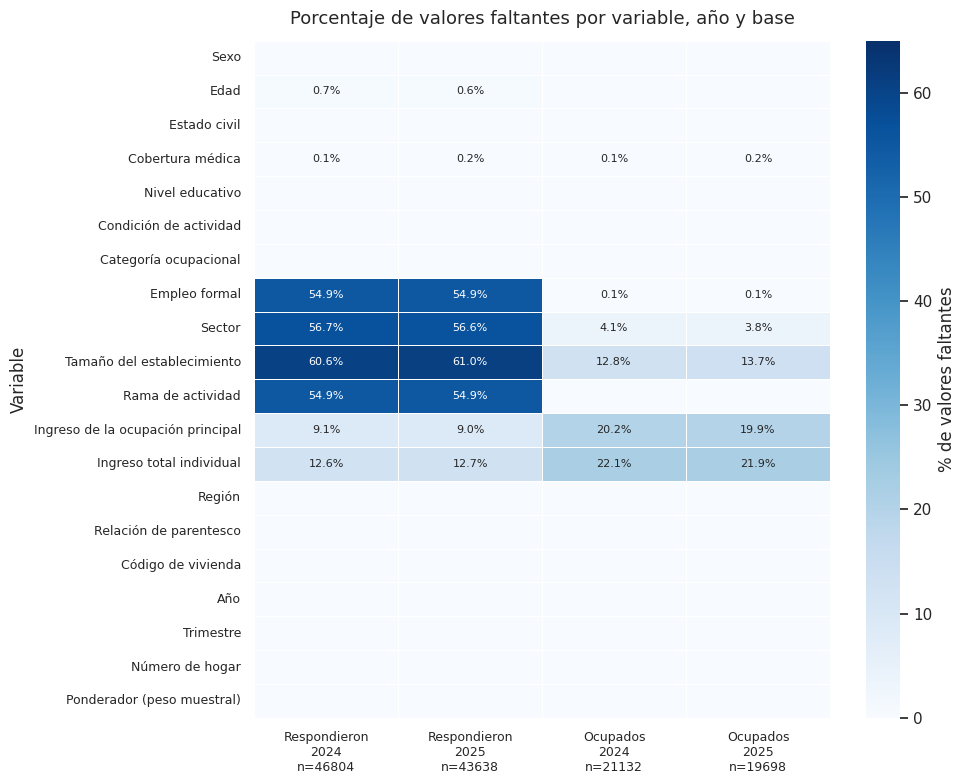

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    tabla_heatmap,
    annot=etiquetas,
    fmt="",
    cmap="Blues",
    vmin=0,
    vmax=vmax,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "% de valores faltantes"},
    annot_kws={"fontsize": 8},
    ax=ax
)

ax.set_title(
    "Porcentaje de valores faltantes por variable, año y base",
    fontsize=13,
    pad=12
)

ax.set_xlabel("")
ax.set_ylabel("Variable")

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
    ha="center",
    fontsize=9
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    "heatmap_faltantes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**PARTE 2: Primer Análisis Exploratorio**

**8)** Matriz de correlación para 2024T4 y 2025T4 con las siguientes variables:

SECTOR, ESTADO, CAT_OCU, P21_2025T4, P47T_2025T4, NIVEL ED, CH04, CH06, CH07, CH08.

In [ ]:
import seaborn as sns

variables_corr = ['SECTOR', 'ESTADO', 'CAT_OCUP', 'P21', 'P47T','NIVEL_ED', 'CH04', 'CH06', 'CH07', 'CH08']

df_corr = respondieron[['anio_base'] + variables_corr].copy()

df_corr_2024 = df_corr[df_corr['anio_base'] == 2024]
df_corr_2025 = df_corr[df_corr['anio_base'] == 2025]

#Matrices de correlación:
corr_2024 = df_corr_2024[variables_corr].corr()
corr_2025 = df_corr_2025[variables_corr].corr()

In [ ]:
corr_2024 = corr_2024.rename(index=etiquetas_variables, columns=etiquetas_variables)
corr_2025 = corr_2025.rename(index=etiquetas_variables, columns=etiquetas_variables)

In [ ]:
print(etiquetas_variables)

{'CH04': 'Sexo', 'CH06': 'Edad', 'CH07': 'Estado civil', 'CH08': 'Cobertura médica', 'NIVEL_ED': 'Nivel educativo', 'ESTADO': 'Condición de actividad', 'CAT_OCUP': 'Categoría ocupacional', 'EMPLEO': 'Empleo formal', 'SECTOR': 'Sector', 'PP04C': 'Tamaño del establecimiento', 'PP04D_COD': 'Rama de actividad', 'P21': 'Ingreso de la ocupación principal', 'P47T': 'Ingreso total individual', 'REGION': 'Región', 'CH03': 'Relación de parentesco', 'CODUSU': 'Código de vivienda', 'ANO4': 'Año', 'TRIMESTRE': 'Trimestre', 'NRO_HOGAR': 'Número de hogar', 'PONDERA': 'Ponderador (peso muestral)'}


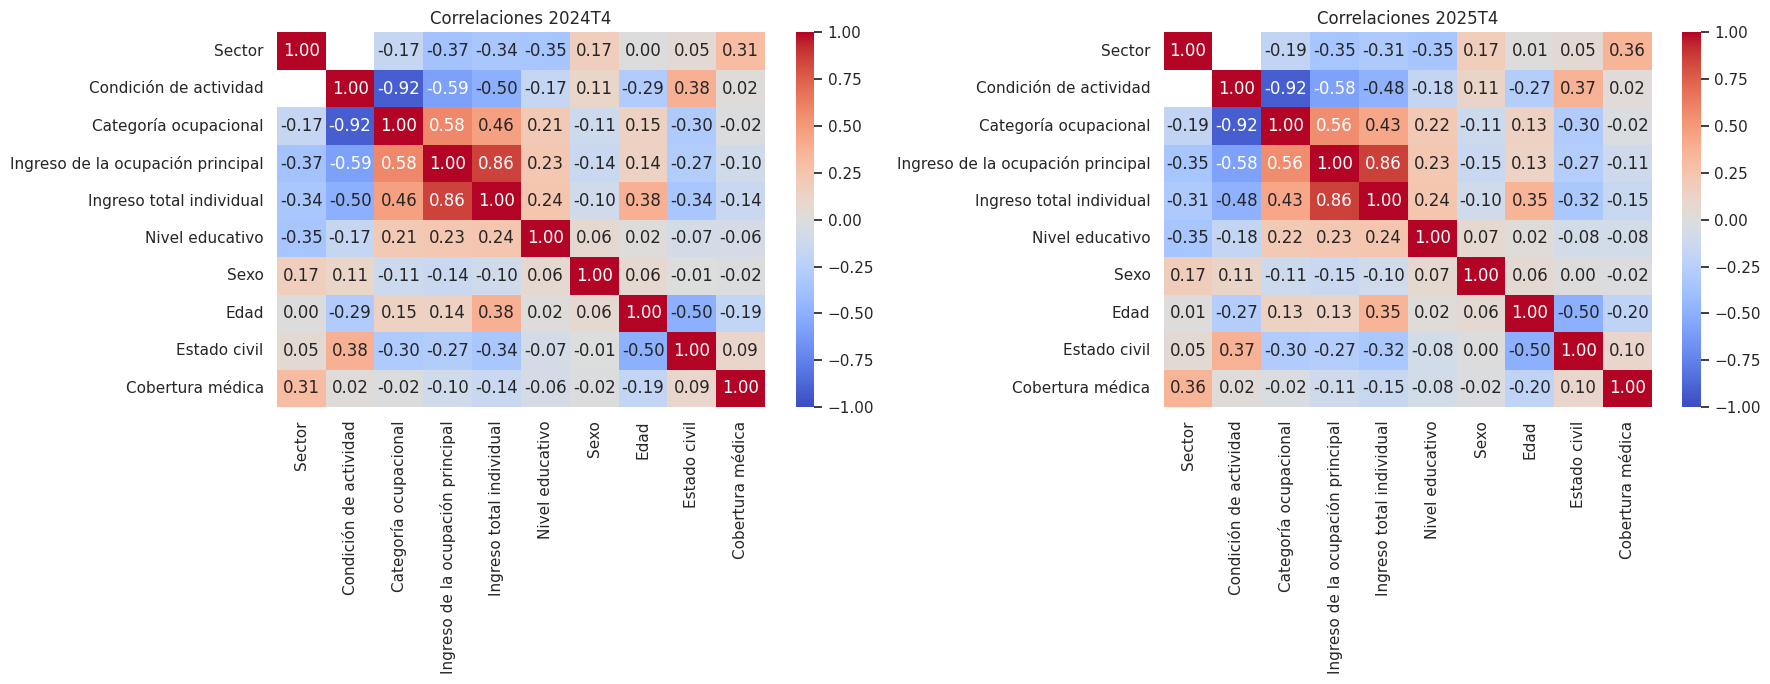

In [ ]:
# Grafico ambos heatmaps en una misma figura con variables categoricas no binarias (no será presentado en el informe)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    corr_2024,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    ax=axes[0]
)

axes[0].set_title("Correlaciones 2024T4")

sns.heatmap(
    corr_2025,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    ax=axes[1]
)

axes[1].set_title("Correlaciones 2025T4")

plt.tight_layout()

# Guardar imagen
plt.savefig("heatmap_correlaciones_2024_2025_categirucas.png", dpi=300, bbox_inches="tight")

plt.show()


 Matriz de correlación para 2024T4 y 2025T4 con las siguientes variables binarias:

'sector_formal','sector_informal','sector_hogares','Ocupado','Desocupado','Inactivo','patron','cuenta_propia','asalariado','trabajador_familiar_sin_remuneracion','P21','P47T','secundario_completo_o_mas','superior_completo','mujer','CH06','con_pareja','tiene_cobertura_medica'

In [ ]:
import seaborn as sns

variables_corr = ['sector_formal','sector_informal','sector_hogares','Ocupado','Desocupado','Inactivo','patron','cuenta_propia','asalariado','trabajador_familiar_sin_remuneracion','P21','P47T','secundario_completo_o_mas','superior_completo','mujer','CH06','con_pareja','tiene_cobertura_medica']

df_corr = respondieron[['anio_base'] + variables_corr].copy()

df_corr_2024 = df_corr[df_corr['anio_base'] == 2024]
df_corr_2025 = df_corr[df_corr['anio_base'] == 2025]

#Matrices de correlación:
corr_2024 = df_corr_2024[variables_corr].corr()
corr_2025 = df_corr_2025[variables_corr].corr()

In [ ]:
corr_2024 = corr_2024.rename(index=etiquetas_variables, columns=etiquetas_variables)
corr_2025 = corr_2025.rename(index=etiquetas_variables, columns=etiquetas_variables)
corr_2024_renombrada = corr_2024.rename(index=etiquetas_binarias, columns=etiquetas_binarias)
corr_2025_renombrada = corr_2025.rename(index=etiquetas_binarias, columns=etiquetas_binarias)

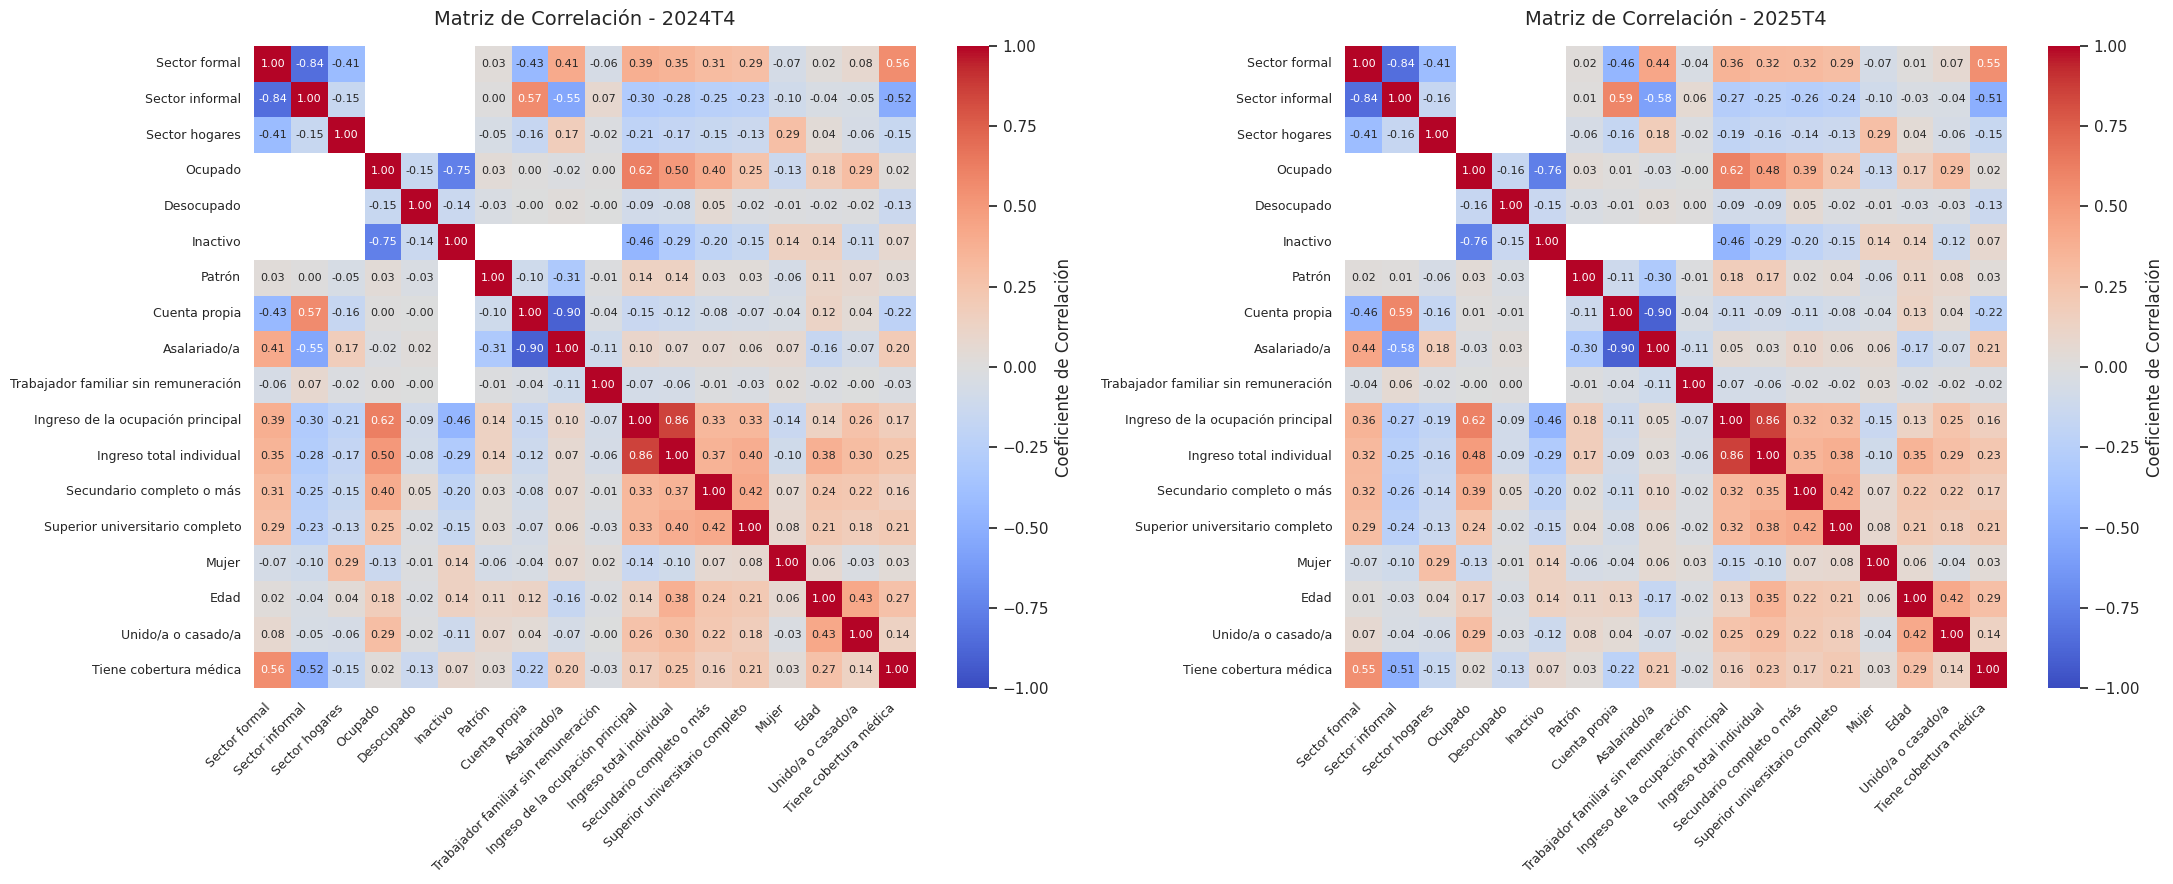

In [ ]:
# Grafico ambos heatmaps en una misma figura
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
sns.heatmap(
    corr_2024_renombrada,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    ax=axes[0],
    cbar_kws={'label': 'Coeficiente de Correlación'},
    annot_kws={"size": 8}
)

axes[0].set_title("Matriz de Correlación - 2024T4", fontsize=14, pad=15)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=9)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=9)

sns.heatmap(
    corr_2025_renombrada,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    ax=axes[1],
    cbar_kws={'label': 'Coeficiente de Correlación'},
    annot_kws={"size": 8}
)

axes[1].set_title("Matriz de Correlación - 2025T4", fontsize=14, pad=15)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=9)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()

# Guardar imagen
plt.savefig("heatmap_correlaciones_2024_2025.png", dpi=300, bbox_inches="tight")

plt.show()

**9)** Tabla de estadistica descriptiva

In [ ]:
variables_continuas = ['CH06','P21_2025T4','P47T_2025T4']
etiquetas_continuas = {
    'CH06': 'Edad',
    'P21_2025T4': 'Ingreso ocupación principal, pesos 2025T4',
    'P47T_2025T4': 'Ingreso total, pesos 2025T4'
}
variables_tabla_desc = variables_continuas + variables_binarias
df_desc = respondieron[['anio_base'] + variables_tabla_desc].copy()

for var in variables_tabla_desc:
    df_desc[var] = pd.to_numeric(df_desc[var], errors='coerce').astype(float)

In [ ]:
# Defino percentiles con nombre
def p1(x):
    return x.quantile(0.01)
def p25(x):
    return x.quantile(0.25)
def p50(x):
    return x.quantile(0.50)
def p75(x):
    return x.quantile(0.75)
def p99(x):
    return x.quantile(0.99)

# Tabla descriptiva por año
tabla_desc = df_desc.groupby('anio_base')[variables_tabla_desc].agg([
    'count','mean','std','min',p1,p25,p50,p75,p99,'max'])

# Renombro estadísticas
tabla_desc = tabla_desc.rename(columns={
    'count': 'n',
    'mean': 'media',
    'std': 'desvio_estandar'
}, level=1)

# Paso las variables a filas
tabla_desc_larga = tabla_desc.stack(level=0).reset_index()

# Renombro columna de variable
tabla_desc_larga = tabla_desc_larga.rename(columns={
    'level_1': 'variable'
})

# Ordeno columnas
tabla_desc_larga = tabla_desc_larga[
    ['anio_base', 'variable', 'n', 'media', 'desvio_estandar',
     'min', 'p1', 'p25', 'p50', 'p75', 'p99', 'max']
]

# Ordeno las variables según el orden definido arriba
tabla_desc_larga['orden_variable'] = pd.Categorical(
    tabla_desc_larga['variable'],
    categories=variables_tabla_desc,
    ordered=True
)

tabla_desc_larga = tabla_desc_larga.sort_values(
    ['orden_variable', 'anio_base']
).reset_index(drop=True)

# Armo diccionario de etiquetas legibles
etiquetas_variables = {}
etiquetas_variables.update(etiquetas_continuas)
etiquetas_variables.update(etiquetas_binarias)

# Cambio nombres técnicos por nombres entendibles
tabla_desc_larga['variable'] = tabla_desc_larga['variable'].map(etiquetas_variables)

# Elimino columna auxiliar
tabla_desc_larga = tabla_desc_larga.drop(columns='orden_variable')

# Redondeo para que sea más prolijo
tabla_desc_larga[['media', 'desvio_estandar', 'min', 'p1', 'p25', 'p50', 'p75', 'p99', 'max']] = (
    tabla_desc_larga[['media', 'desvio_estandar', 'min', 'p1', 'p25', 'p50', 'p75', 'p99', 'max']]
    .round(2)
)

tabla_desc_larga


/tmp/ipykernel_1495/507263182.py:25: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  tabla_desc_larga = tabla_desc.stack(level=0).reset_index()


,anio_base,variable,n,media,desvio_estandar,min,p1,p25,p50,p75,p99,max
0,2024,Edad,46498,37.01,22.05,1.0,2.0,19.0,35.00,54.00,85.0,103.0
1,2025,Edad,43391,37.81,22.20,1.0,2.0,19.0,36.00,55.00,86.0,101.0
2,2024,"Ingreso ocupación principal, pesos 2025T4",42529,352741.81,698449.41,0.0,0.0,0.0,0.00,536980.28,2826212.0,21196590.0
3,2025,"Ingreso ocupación principal, pesos 2025T4",39724,364445.37,727927.61,0.0,0.0,0.0,0.00,600000.00,3000000.0,30000000.0
4,2024,"Ingreso total, pesos 2025T4",40900,528851.52,789447.85,0.0,0.0,0.0,339145.44,769163.49,3532765.0,23316249.0
...,...,...,...,...,...,...,...,...,...,...,...,...
61,2025,Cuyo,43638,0.10,0.30,0.0,0.0,0.0,0.00,0.00,1.0,1.0
62,2024,Pampeana,46804,0.30,0.46,0.0,0.0,0.0,0.00,1.00,1.0,1.0
63,2025,Pampeana,43638,0.31,0.46,0.0,0.0,0.0,0.00,1.00,1.0,1.0
64,2024,Patagonia,46804,0.12,0.33,0.0,0.0,0.0,0.00,0.00,1.0,1.0


In [ ]:
tabla_desc_larga.to_csv("tabla_desc_larga.csv", index=False)

from google.colab import files
files.download("tabla_desc_larga.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
tabla_desc_larga.to_excel('tabla_desc_larga.xlsx', index=False)

**PARTE 3: Conociendo la informalidad laboral**

**10)** Genero el indicador de 'work_status' según la definición de Maurizo & Monsalvo (2021). formal_self_employed: Dueños de empresas con más de 5 empleados y profesionales independientes.  

Actualizo 'ocupados' para que tenga las variables de binarias y de ingresos actualizadas

In [ ]:
ocupados = respondieron[((respondieron['patron'] == 1) | (respondieron['cuenta_propia'] == 1))].copy()

In [ ]:
print("respondieron: ", len(respondieron))
print("dueños y cuentapropistas: ", len(ocupados))

respondieron:  90442
dueños y cuentapropistas:  11852


In [ ]:
ocupados['duenio_empresa_mas_5'] = crear_binaria(
    (ocupados['PP04C'].isin([6, 7, 8, 9, 10, 11, 12])),
    ocupados['CAT_OCUP'].isin([1, 2, 3, 4])
)

ocupados['profesional_independiente'] = crear_binaria(
    (ocupados['superior_completo'] == 1),
    ocupados['CAT_OCUP'].isin([1, 2, 3, 4])
)

ocupados['formal_self_employed'] = crear_binaria(
    (ocupados['duenio_empresa_mas_5'] == 1) |
    (ocupados['profesional_independiente'] == 1),
    ocupados['CAT_OCUP'].isin([1, 2, 3, 4])
)

In [ ]:
ocupados.groupby('anio_base')[
    ['duenio_empresa_mas_5', 'profesional_independiente', 'formal_self_employed']
].mean()

,duenio_empresa_mas_5,profesional_independiente,formal_self_employed
anio_base,,,
2024,0.032355,0.197821,0.217770
2025,0.031425,0.192288,0.209445


In [ ]:
base_fse = ocupados.dropna(subset=['formal_self_employed']).copy()

base_fse['condicion'] = base_fse['formal_self_employed'].map({
    1: 'Formal',
    0: 'Informal'
})

base_fse['grupo'] = base_fse['mujer'].map({
    1: 'Mujeres',
    0: 'Hombres'
})

In [ ]:
tabla_sexo = (
    base_fse
    .groupby(['anio_base', 'grupo'])['condicion']
    .value_counts(normalize=True)
    .mul(100)
    .rename('porcentaje')
    .reset_index()
)

In [ ]:
tabla_total = (
    base_fse
    .groupby('anio_base')['condicion']
    .value_counts(normalize=True)
    .mul(100)
    .rename('porcentaje')
    .reset_index()
)

tabla_total['grupo'] = 'Total'

In [ ]:
tabla_formalidad = pd.concat(
    [tabla_total, tabla_sexo],
    ignore_index=True
)

tabla_formalidad_doble = (
    tabla_formalidad
    .pivot_table(
        index=['anio_base', 'grupo'],
        columns='condicion',
        values='porcentaje'
    )
    .reset_index()
)

# Ordeno filas
orden_grupos = ['Total', 'Mujeres', 'Hombres']

tabla_formalidad_doble['grupo'] = pd.Categorical(
    tabla_formalidad_doble['grupo'],
    categories=orden_grupos,
    ordered=True
)

tabla_formalidad_doble = (
    tabla_formalidad_doble
    .sort_values(['anio_base', 'grupo'])
    .reset_index(drop=True)
)

# Redondeo
tabla_formalidad_doble[['Formal', 'Informal']] = (
    tabla_formalidad_doble[['Formal', 'Informal']].round(2)
)

tabla_formalidad_doble

condicion,anio_base,grupo,Formal,Informal
0,2024,Total,21.78,78.22
1,2024,Mujeres,27.11,72.89
2,2024,Hombres,18.32,81.68
3,2025,Total,20.94,79.06
4,2025,Mujeres,25.81,74.19
5,2025,Hombres,17.59,82.41


In [ ]:
tabla_formalidad_doble.to_excel("tabla_formalidad_doble.xlsx", index=False)

**11)** Visualización de Distribución de Ingresos

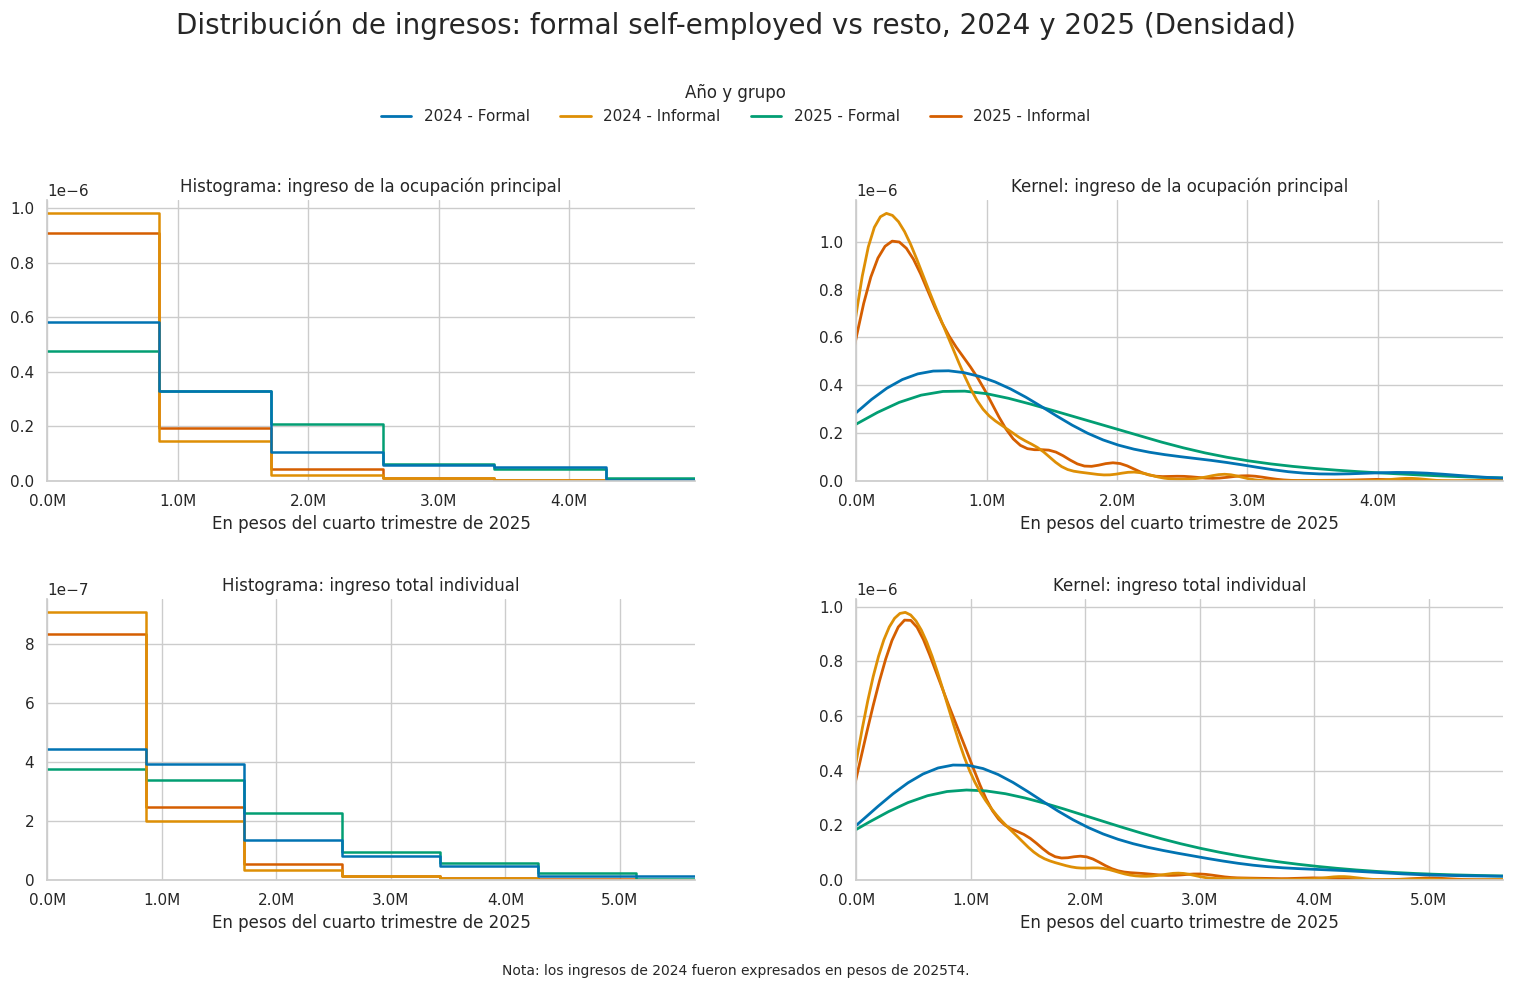

In [ ]:
from matplotlib.lines import Line2D

# Base para el gráfico
base_grafico = ocupados.dropna(
    subset=['formal_self_employed', 'P21_2025T4', 'P47T_2025T4', 'anio_base']
).copy()
# Etiqueta clara del grupo
base_grafico['grupo_fse'] = base_grafico['formal_self_employed'].map({
    1: 'Formal',
    0: 'Informal'
})

# Etiqueta de año
base_grafico['anio'] = base_grafico['anio_base'].astype(str)

# Grupo final para graficar
base_grafico['grupo_grafico'] = (
    base_grafico['anio'] + ' - ' + base_grafico['grupo_fse']
)
#al final decidimos no usar Log
# Logaritmo de ingresos
#base_grafico['log_P21'] = np.log1p(base_grafico['P21_2025T4'])
#base_grafico['log_P47T'] = np.log1p(base_grafico['P47T_2025T4'])

# Orden de los grupos
orden_grupos = [
    '2024 - Formal',
    '2024 - Informal',
    '2025 - Formal',
    '2025 - Informal'
]

# Paleta simple y consistente
colores = sns.color_palette("colorblind", n_colors=4)

palette = {
    grupo: color
    for grupo, color in zip(orden_grupos, colores)
}

# Estilo limpio
sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1: Histograma P21
sns.histplot(
    data=base_grafico,
    x='P21_2025T4',
    hue='grupo_grafico',
    hue_order=orden_grupos,
    palette=palette,
    bins=35,
    stat='density',
    common_norm=False,
    element='step',
    fill=False,
    linewidth=1.8,
    ax=axes[0, 0]
)

axes[0, 0].set_title('Histograma: ingreso de la ocupación principal')
axes[0, 0].set_xlabel('En pesos del cuarto trimestre de 2025')
#axes[0, 0].set_ylabel('Densidad')

# Panel 2: Kernel P21
sns.kdeplot(
    data=base_grafico,
    x='P21_2025T4',
    hue='grupo_grafico',
    hue_order=orden_grupos,
    palette=palette,
    common_norm=False,
    linewidth=2,
    ax=axes[0, 1]
)

axes[0, 1].set_title('Kernel: ingreso de la ocupación principal')
axes[0, 1].set_xlabel('En pesos del cuarto trimestre de 2025')
#axes[0, 1].set_ylabel('Densidad')

# Panel 3: Histograma P47T
sns.histplot(
    data=base_grafico,
    x='P47T_2025T4',
    hue='grupo_grafico',
    hue_order=orden_grupos,
    palette=palette,
    bins=35,
    stat='density',
    common_norm=False,
    element='step',
    fill=False,
    linewidth=1.8,
    ax=axes[1, 0]
)

axes[1, 0].set_title('Histograma: ingreso total individual')
axes[1, 0].set_xlabel('En pesos del cuarto trimestre de 2025')
#axes[1, 0].set_ylabel('Densidad')

# Panel 4: Kernel P47T
sns.kdeplot(
    data=base_grafico,
    x='P47T_2025T4',
    hue='grupo_grafico',
    hue_order=orden_grupos,
    palette=palette,
    common_norm=False,
    linewidth=2,
    ax=axes[1, 1]
)

axes[1, 1].set_title('Kernel: ingreso total individual')
axes[1, 1].set_xlabel('En pesos del cuarto trimestre de 2025')
axes[1, 1].set_ylabel('Densidad')

# Quito leyendas repetidas de cada panel
for ax in axes.flat:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # Quito título del eje y
    ax.set_ylabel('')

    # Menos ruido visual
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# Leyenda única general
grupos_presentes = [
    grupo for grupo in orden_grupos
    if grupo in base_grafico['grupo_grafico'].unique()
]

handles = [
    Line2D([0], [0], color=palette[grupo], lw=2, label=grupo)
    for grupo in grupos_presentes
]

fig.legend(
    handles=handles,
    title='Año y grupo',
    loc='upper center',
    bbox_to_anchor=(0.5, 0.93),
    ncol=4,
    frameon=False
)

# Título general
fig.suptitle(
    'Distribución de ingresos: formal self-employed vs resto, 2024 y 2025 (Densidad)',
    fontsize=20,
    y=0.99
)

# Nota al pie separada
fig.text(
    0.5,
    0.025,
    'Nota: los ingresos de 2024 fueron expresados en pesos de 2025T4.',
    ha='center',
    fontsize=10
)

# Ajuste manual del espacio
plt.subplots_adjust(
    top=0.80,
    bottom=0.12,
    left=0.07,
    right=0.98,
    hspace=0.42,
    wspace=0.25
)

# --- Trimming de valores extremos (percentil 99) ---
limite_p21 = base_grafico['P21_2025T4'].quantile(0.99)
limite_p47t = base_grafico['P47T_2025T4'].quantile(0.99)

axes[0, 0].set_xlim(0, limite_p21)   # Histograma P21
axes[0, 1].set_xlim(0, limite_p21)   # Kernel P21
axes[1, 0].set_xlim(0, limite_p47t)  # Histograma P47T
axes[1, 1].set_xlim(0, limite_p47t)  # Kernel P47T

#pasamos a millones el eje
from matplotlib.ticker import FuncFormatter

def formato_millones(x, pos):
    return f'{x/1e6:.1f}M'

for ax in axes.flat:
    ax.xaxis.set_major_formatter(FuncFormatter(formato_millones))






plt.savefig(
    'distribucion_ingresos_formal_self_employed_vs_resto.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()